# Lab 01: Fitting a Line When Your Data Are Lying to You

**ASTR 457, Fall 2026 — posted Thu Sep 3, due Wed Sep 9 by Noon (fork → PR, as always)**

*Why this lab: fitting a line to contaminated data is the statistic behind real discoveries (it's how Gaia BH1's dark companion was found), and refereeing someone else's fit — including a machine's — is the skill you'll use in every collaboration, every review, and every AI-assisted analysis for the rest of your career.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `x`, `y`, `sigma_y`.
It was generated from a straight line, $y = mx + b$, with Gaussian noise of the stated
$\sigma_y$ — except that some fraction of the points are **outliers** drawn from a much
broader distribution. I know the true $m$, $b$, and outlier fraction for your dataset.
You don't, and you can't look them up, and your classmates' values are different from yours.

**How this is graded.** Not on whether your code runs — on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$m$ and $b$ are to your truth **in units of your own reported uncertainty**. Report tiny
error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.

**AI policy reminder.** Use whatever tools you like, including AI assistants — and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The naive fit (20%)

Load your dataset and fit a straight line by **weighted least squares**, using the reported
`sigma_y` and all the data points. Report $m \pm \sigma_m$ and $b \pm \sigma_b$, plot the
data (with error bars) and your fit, and compute the reduced $\chi^2$.

Then answer, in a few sentences: what is the reduced $\chi^2$ telling you, and why is it
doing that? Would you trust these error bars? (This fit is *supposed* to be bad. Understanding
exactly how it is bad is the point.)

naive fit: slope=2.76 ± 0.12, intercept=47.80 ± 0.63, chi2_red=12.68 


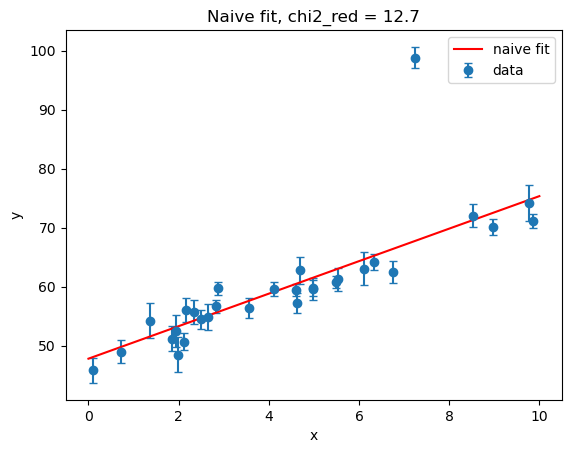

In [1]:
# Part 1: your work here
import numpy as np
import matplotlib.pyplot as plt

x,y,sy = np.genfromtxt("acm18.csv", delimiter = ',', names = True,unpack = True)
n = len(x)

coef, cov_matrix = np.polyfit(x, y, 1, w=1/sy,cov = 'unscaled')
resid = y - np.polyval(coef, x)
chi2 = np.sum((resid / sy) ** 2)
chi2_red = chi2 / (n - 2)
errors = np.sqrt(np.diag(cov_matrix))
print(f"naive fit: slope={coef[0]:.2f} ± {errors[0]:.2f}, intercept={coef[1]:.2f} ± {errors[1]:.2f}, "
      f"chi2_red={chi2_red:.2f} ")

xx = np.linspace(0, 10, 200)
plt.errorbar(x, y, yerr=sy, fmt='o', capsize=3, label='data')
plt.plot(xx, np.polyval(coef, xx), 'r-', label='naive fit')
plt.xlabel('x'); plt.ylabel('y'); plt.legend()
plt.title(f'Naive fit, chi2_red = {chi2_red:.1f}')
plt.show()

**ANSWER (a few sentences):**

The reduced $\chi^2$ is a metric that scales the goodness of fit around the number 1. In this situation the reduced $\chi^2$ is telling me that this data is underfitted or the error bars are too small. This is most likely a response of the line wanting to include the one far outlier, weighing it heavier because it has a small $\sigma_y$, and then missing the error bars of many of the lower points. I would not trust these error bars for the coeffecient values becuase my choice to keep them unscalled in this case has made them too small and most likely do not include the true value.

## Part 2: A fit you can defend (40%)

Now deal with the outliers. Do this **two ways**:

1. **Sigma-clipping**: iteratively remove points that are discrepant with the fit, refit,
   and repeat until it converges. Be explicit about your clipping threshold and why you chose it.
2. **A mixture model**: model each point as coming from either the line (with its stated
   $\sigma_y$) or from a broader outlier distribution, and maximize the appropriate likelihood
   (see Hogg, Bovy & Lang 2010, §3, for the canonical treatment — this is the same problem
   with different numbers).

For each method report $m \pm \sigma_m$, $b \pm \sigma_b$, and (for the mixture) your
estimate of the outlier fraction. Then commit to a **final answer** — one set of numbers
you'd put in a paper — and justify the choice. State clearly how you estimated your
uncertainties and why you believe them.

3-sigma clip: slope=2.48 ± 0.12, intercept=47.91 ± 0.67, chi2_red=0.94, clipped 2 of 30 points


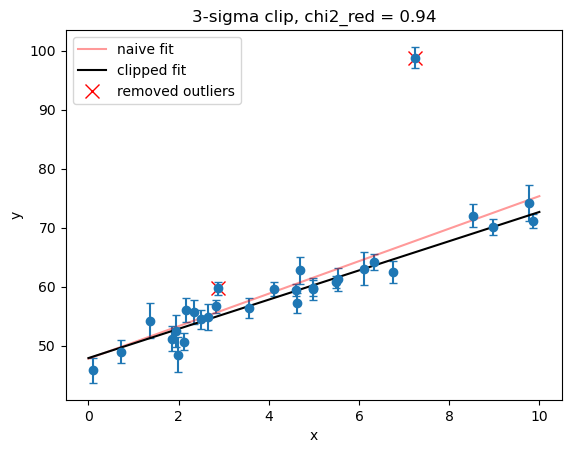

In [2]:
# Part 2: your work here
''' I chose to clip over sigma=3 so that I am still including 98% of the data. The 3 sigma clip ensures that the only data removed is the farthest outliers'''
def sigma_clip_fit(x, y, sigma, k=3.0, max_iter=10):
    mask = np.ones_like(x, dtype=bool)
    for _ in range(max_iter):
        coef, cov_matrix = np.polyfit(x[mask], y[mask], 1, w=1/sigma[mask],cov = 'unscaled')
        resid = (y - np.polyval(coef, x)) / sigma
        new_mask = np.abs(resid) < k
        if np.array_equal(new_mask, mask):
            break
        mask = new_mask
    return coef, mask, cov_matrix

coef_clip, mask, cov_matrix = sigma_clip_fit(x, y, sy, k=3.0)
resid = y[mask] - np.polyval(coef_clip, x[mask])
chi2_red_clip = np.sum((resid / sy[mask]) ** 2) / (mask.sum() - 2)
errors = np.sqrt(np.diag(cov_matrix))
print(f"3-sigma clip: slope={coef_clip[0]:.2f} ± {errors[0]:.2f}, intercept={coef_clip[1]:.2f} ± {errors[1]:.2f}, "
      f"chi2_red={chi2_red_clip:.2f}, clipped {(~mask).sum()} of {n} points")
plt.errorbar(x, y, yerr=sy, fmt='o', capsize=3, color='C0')
plt.plot(xx, np.polyval(coef, xx), 'r-', alpha=0.4, label='naive fit')
plt.plot(xx, np.polyval(coef_clip, xx), label='clipped fit', c = 'k')
plt.plot(x[~mask], y[~mask], 'rx', ms=10, label='removed outliers')
plt.xlabel('x'); plt.ylabel('y'); plt.legend()
plt.title(f'3-sigma clip, chi2_red = {chi2_red_clip:.2f}')
plt.show()

mixture fit: slope=2.47 ± 0.15, intercept=47.95 ± 0.93, outlier fraction Pb=0.07


Text(0.5, 1.0, 'Mixed Model, chi2_red = 15.1')

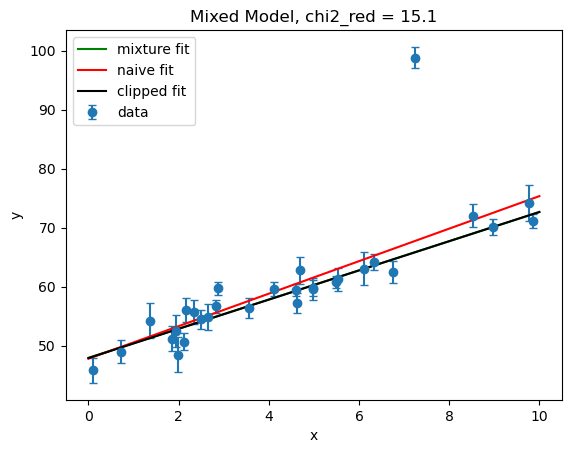

In [3]:
from scipy.optimize import minimize
from scipy.stats import norm

def neg_log_likelihood(theta, x, y, sigma):
    m, b, Pb, Yb, lnVb = theta
    Pb = np.clip(Pb, 1e-6, 1 - 1e-6)
    Vb = np.exp(lnVb)
    model = m * x + b
    good = (1 - Pb) * norm.pdf(y, loc=model, scale=sigma)
    bad_pop = Pb * norm.pdf(y, loc=Yb, scale=np.sqrt(Vb + sigma**2))
    return -np.sum(np.log(good + bad_pop + 1e-300))

theta0 = [coef_clip[0], coef_clip[1], 0.2, np.mean(y), np.log(50.0)]
result = minimize(neg_log_likelihood, theta0, args=(x, y, sy), method='Nelder-Mead')
m_mix, b_mix, Pb_mix, Yb_mix, lnVb_mix = result.x
resid = y - (x* m_mix + b_mix) 
chi2_red_mix = np.sum((resid / sy) ** 2) / (n-5)


rng_bs = np.random.default_rng(20260908)
n_boot = 2000

boot_slopes = np.empty(n_boot)
boot_int = np.empty(n_boot)
for i in range(n_boot):
    idx = rng_bs.integers(0, n, size=n)
    result = minimize(neg_log_likelihood, theta0, args=(x[idx], y[idx], sy[idx]), method='Nelder-Mead')
    m_mix_bs, b_mix_bs, Pb_mix_bs, Yb_mix_bs, lnVb_mix_bs = result.x
    boot_slopes[i] = m_mix_bs
    boot_int[i] = b_mix_bs

std_slope = np.std(boot_slopes)
std_int = np.std(boot_int)


print(f"mixture fit: slope={m_mix:.2f} ± {std_slope:.2f}, intercept={b_mix:.2f} ± {std_int:.2f}, "
      f"outlier fraction Pb={Pb_mix:.2f}")


plt.plot(xx, m_mix * xx + b_mix, 'g-', label='mixture fit')
plt.errorbar(x, y, yerr=sy, fmt='o', capsize=3, label='data')
plt.plot(xx, np.polyval(coef, xx), 'r-', label='naive fit')
plt.plot(xx, np.polyval(coef_clip, xx), label='clipped fit', c = 'k')


plt.xlabel('x'); plt.ylabel('y'); plt.legend()
plt.title(f'Mixed Model, chi2_red = {chi2_red_mix:.1f}')

**FINAL ANSWER:** $m = $ 2.47 $\pm$ 0.15, $b = $ 47.95 $\pm$ .93 , outlier fraction $\approx$ 0.07
**Justification and uncertainty method (a short paragraph):**

The numbers that I have chosen to report are from my mixture model. When looking at the diferent methods the mixture model appears to be the most robust and has less of a reliance on a chosen free parameter than sigma clipping. This model takes all of the data into consideration and weights outliers less than other values but still takes them into account. To determine my uncertainty I used bootstrapping: I sampled my data with replacement 2000 times to create arrays of m and b values. I then used the standard deviations of those values to reprisent my error. This should create a 68% confidence interval, assuring that if this procedure were repeated 100 times 68 of the error bars would contain the true population value. With my confidence in the mixture model to approximate the true line I believe that this one sigma range should be sufficient in reporting the true value. 

Additionally the mixture model passes all of my Verification check at the end of this notebook.

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis of
this exact problem, produced by an AI assistant. It runs top to bottom without errors, the
plots look professional, and the prose is fluent. It is also wrong — in at least **three**
distinct, substantive ways (cosmetic nitpicks don't count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset — show, with a number or a plot,
   what the error does to the inference. "This is bad practice" is not a demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

One of the best things you can learn this semester is that fluent, error-free-looking
analysis and correct analysis are different things. Referee accordingly.

**REFEREE REPORT:**

*Flaw 1:*
The ai did not give np.polyfit the weights for each point. 

*Flaw 2:*
Only clipped once, instead of creating a sigma clip funtion that converges on a set of good points, the AI only clipped once

*Flaw 3:*
Scalling measurment uncertainties so that $\chi^2$ is one. The AI scalled all errors so that $\chi^2$ is one, this leads to over


naive fit: slope=2.76, intercept=47.80
AI fit: slope=3.00, intercept=46.90


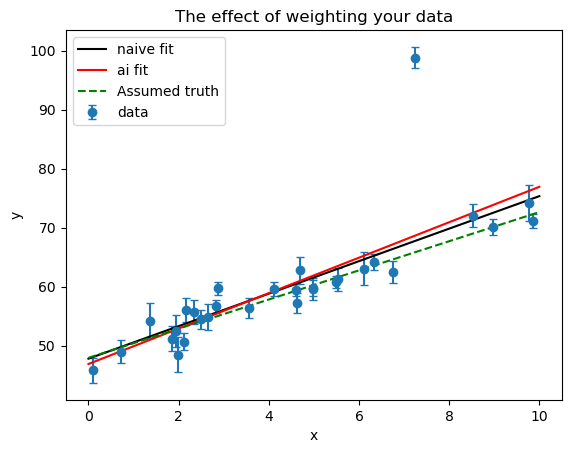

In [4]:
# Part 3: demonstrations here
'''Flaw 1'''
ai_coeffs, ai_cov = np.polyfit(x, y, 1, cov=True)
coef, cov_matrix = np.polyfit(x, y, 1, w=1/sy,cov = 'unscaled')


plt.errorbar(x, y, yerr=sy, fmt='o', capsize=3, label='data')
plt.plot(xx, np.polyval(coef, xx), 'k-', label='naive fit')
plt.plot(xx, np.polyval(ai_coeffs, xx), 'r-', label='ai fit')
plt.plot(xx, m_mix * xx + b_mix, 'g--', label='Assumed truth')



plt.xlabel('x'); plt.ylabel('y'); plt.legend()
plt.title('The effect of weighting your data')

print(f"naive fit: slope={coef[0]:.2f}, intercept={coef[1]:.2f}\nAI fit: slope={ai_coeffs[0]:.2f}, intercept={ai_coeffs[1]:.2f}")

### Flaw 1

By weighting each point by its own error our model is able to take into account the sensitivity of each point. This effect will change depending on what points are noisy and if that corresponds to outliers but it is still good practice to use the y errors to inform the model. In my choosen example case we can see that the incorperation of weights has made the naive fit mutch closer to the truth than the ai's method. When given an error for the y values it is best practice to use it to weight your model to better inform the components of your fit.

naive fit: slope=2.48, intercept=47.91
 AI fit: slope=2.55, intercept=47.79


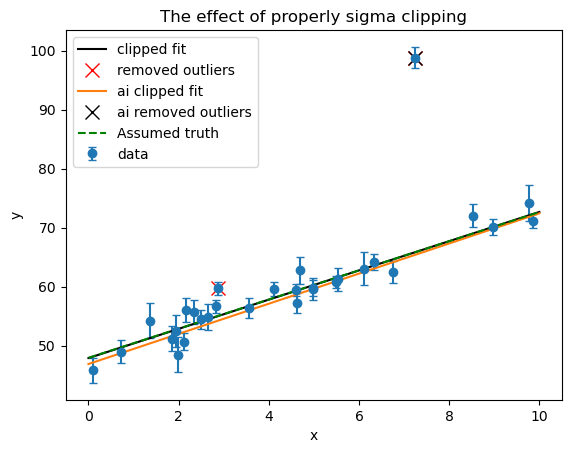

In [5]:
'''Flaw 2'''
ai_coeffs, ai_cov = np.polyfit(x, y, 1, cov=True)
ai_m_fit, ai_b_fit = ai_coeffs
ai_residuals = y - (ai_m_fit * x + ai_b_fit)
ai_threshold = 3 * np.std(ai_residuals)
ai_mask = np.abs(ai_residuals) < ai_threshold


ai_coeffs, cov = np.polyfit(x[ai_mask], y[ai_mask], 1, cov=True)
ai_m_fit, aib_fit = ai_coeffs

coef_clip, mask, cov_matrix = sigma_clip_fit(x, y, sy, k=3.0)

plt.errorbar(x, y, yerr=sy, fmt='o', capsize=3, label='data')
plt.plot(xx, np.polyval(coef_clip, xx), label='clipped fit', c = 'k')
plt.plot(x[~mask], y[~mask], 'rx', ms=10, label='removed outliers')
plt.plot(xx,ai_m_fit * xx + ai_b_fit, label='ai clipped fit')
plt.plot(x[~ai_mask], y[~ai_mask], 'kx', ms=10, label='ai removed outliers')
plt.plot(xx, m_mix * xx + b_mix, 'g--', label='Assumed truth')


plt.xlabel('x'); plt.ylabel('y'); plt.legend()
plt.title('The effect of properly sigma clipping')
print(f"naive fit: slope={coef_clip[0]:.2f}, intercept={coef_clip[1]:.2f}\n AI fit: slope={ai_coeffs[0]:.2f}, intercept={ai_coeffs[1]:.2f}")

### Flaw 2

By only iterating once the ai missed points that lie outside the 98% confidence interval. By iterating until the model converged our 3sigma clipped fit ensures that all outlying data will not have an effect on the final model. When evaluating the coefficient values versus the truth it is clear to see that the 3sigma method has become very accurate by removing outlying data but the ai model has failed to converge on the truth. When desiding to clip outlyers, make sure to iterate until the model converges to obtain the best results.

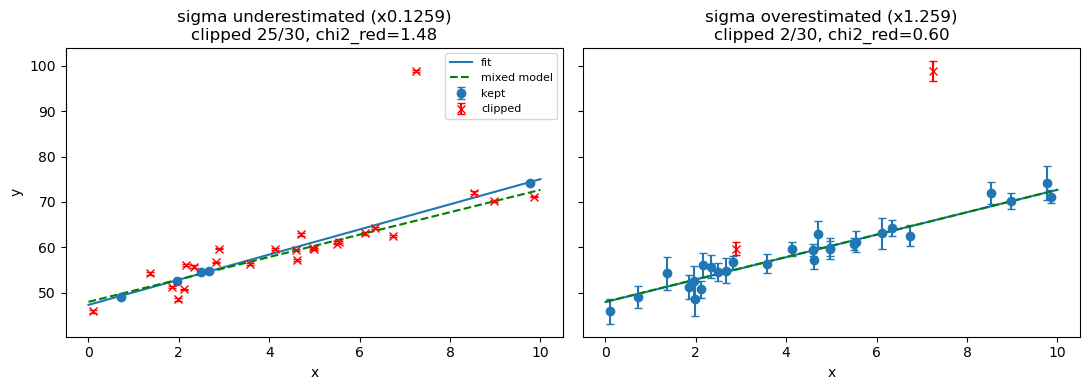

In [6]:
''' Flaw 3 '''
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, factor, label in zip(axes, [0.1259, 1.259], ['sigma underestimated (x0.1259)', 'sigma overestimated (x1.259)']):
    sigma_wrong = sy * factor
    p_w, mask_w, cov_foo = sigma_clip_fit(x, y, sigma_wrong, k=3.0)
    r_w = y[mask_w] - np.polyval(p_w, x[mask_w])
    cr_w = np.sum((r_w / sigma_wrong[mask_w]) ** 2) / (mask_w.sum() - 2)


    ax.errorbar(x[mask_w], y[mask_w], yerr=sigma_wrong[mask_w], fmt='o', capsize=3, color='C0', label='kept')
    ax.errorbar(x[~mask_w], y[~mask_w], yerr=sigma_wrong[~mask_w], fmt='x', capsize=3, color='r', label='clipped')
    ax.plot(xx, np.polyval(p_w, xx), 'C0-', label='fit')
    ax.plot(xx, m_mix * xx + b_mix, 'g--', label='mixed model')
    ax.set_title(f'{label}\nclipped {(~mask_w).sum()}/{n}, chi2_red={cr_w:.2f}')
    ax.set_xlabel('x')
axes[0].set_ylabel('y'); axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

### Flaw 3

Reduced $\chi^2$ on its own is not a good predictor of how good a model is. This is shown clearly above by comparing models with high and low reduced $\chi^2$ values and the both deviate from my found truth in different ways. What the AI does is just scale up the errors by 1.259 to, in its case, get the reduce chi2 statistic to be exactly one. As we can see, just the chi^2 stat does not mean the fit will be better or worse. reduced $\chi^2$ is a measure of how well a model matches your error bars, the correct treatment is to be honest with your errors and report them unscalled.

## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
   what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
   is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers (e.g., residual plots, posterior/parameter sanity checks, refitting on synthetic
   data you generated with known answers). For each check: what would failure have looked like?

**AI-USE APPENDIX:**

I did look up how numpy.polyfit and minimize work on google and read the AI overview along with looking at the actual documentation.

To see how well copilot works I gave it my code for the mixture model and asked it to check how I am calculating reduced $\chi^2$ and give me a methode to find my coefficient errors. Co-Pilot did fix an error I had planted in my $\chi^2$ code where I mask every value and it pointed out to me that the mixture model includes more degrees of freedom than a normal polynomial fit. For the coefficient errors it recomended bootstrapping, which is the method I ended up using. Instead of using the copilot code I adapted the method used in lecture.

**VERIFICATION PLAN:**

##### MAD check 

If I dont trust the given $\sigma_y$ values I could use a mean absolute deviation to approximate the errors. The failure mode for this check would be of MAD significantly deviated from my decided slope value and it does not: the MAD values are included in my Mixed model's error bars.

In [7]:
resid_clip = y - np.polyval(coef_clip, x)
mad = np.median(np.abs(resid_clip - np.median(resid_clip)))
sigma_mad = 1.4826 * mad
print(f"stated sigma (what the data file claims) = {sy[0]:.2f}")
print(f"MAD-based robust sigma, from residuals   = {sigma_mad:.2f}")

p_mad, mask_mad, cov_mad = sigma_clip_fit(x, y, np.full(n, sigma_mad), k=3.0)

mad_errors = np.sqrt(np.diag(cov_mad))

print(f"mixed fit: slope={m_mix:.2f} ± {std_slope:.2f}, intercept={b_mix:.2f} ± {std_int:.2f}, ")
print(f"re-clip with MAD sigma: slope={p_mad[0]:.2f} ± {mad_errors[0]:.2f}, intercept={p_mad[1]:.2f} ± {mad_errors[1]:.2f} ")


stated sigma (what the data file claims) = 2.12
MAD-based robust sigma, from residuals   = 2.09
mixed fit: slope=2.47 ± 0.15, intercept=47.95 ± 0.93, 
re-clip with MAD sigma: slope=2.55 ± 0.15, intercept=47.79 ± 0.74 


##### Bootstrap Error Check

To ensure that bootstrapping my mixed model did not return asymmetric errors I compared my one sigma range to the 68% range. Since these numbers are very close I can trust my error bars. Failure would have been a large discrepancy between these two error ranges.


In [8]:
lo, hi = np.percentile(boot_slopes, [16, 84])
lo_i, hi_i = np.percentile(boot_int, [16, 84])
print(f'slope [{lo:.2f},{hi:.2f}]\nint: [{lo_i:.2f},{hi_i:.2f}]')
print(f'sig_slope: [{m_mix-std_slope:.2f},{m_mix+std_slope:.2f}]\nsig_int: [{b_mix-std_int:.2f},{b_mix+std_int:.2f}]')

slope [2.34,2.63]
int: [47.10,48.75]
sig_slope: [2.32,2.63]
sig_int: [47.02,48.88]


##### see how my chosen model performs on a known line with simulated error

This check applies my model to a line with known value and simulated noise. If my model can properly retrieve the coefficients of the known line then I can be assured that it will work on most simulated lines. The failure mode would be in my models error bars failed to include the true values of this line.

mixture fit: slope=3.15 ± 0.14, intercept=41.76 ± 0.88, outlier fraction Pb=0.17


Text(0.5, 1.0, 'Mixed Model Against a Known Line, chi2_red = 12.7')

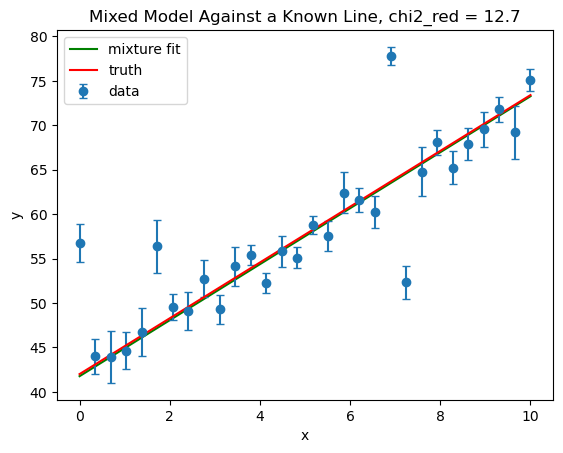

In [9]:

#tx --> true x
#ty --> true y
# I am using the origonal sy point errors to keep things varied
rng = np.random.default_rng(9251970)

n = 30
tx = np.linspace(0, 10, n)
ty_true = 3.14 * tx + 42
sigma = np.full(n, 1.5)
ty = ty_true + rng.normal(0, sigma)

# contaminate 4 points with a much larger, non-Gaussian excursion
bad = rng.choice(n, size=4, replace=False)
ty[bad] += rng.choice([-1, 1], size=4) * rng.uniform(8, 15, size=4)

coef_clip, mask, cov_matrix = sigma_clip_fit(tx, ty, sy, k=3.0)
theta0 = [coef_clip[0], coef_clip[1], 0.2, np.mean(ty), np.log(50.0)]
result = minimize(neg_log_likelihood, theta0, args=(tx, ty, sy), method='Nelder-Mead')
m_mix, b_mix, Pb_mix, Yb_mix, lnVb_mix = result.x
resid = ty - (tx* m_mix + b_mix) 
chi2_red_mix = np.sum((resid / sy) ** 2) / (n-5)


rng_bs = np.random.default_rng(20260908)
n_boot = 2000

boot_slopes = np.empty(n_boot)
boot_int = np.empty(n_boot)
for i in range(n_boot):
    idx = rng_bs.integers(0, n, size=n)
    result = minimize(neg_log_likelihood, theta0, args=(tx[idx], ty[idx], sy[idx]), method='Nelder-Mead')
    m_mix_bs, b_mix_bs, Pb_mix_bs, Yb_mix_bs, lnVb_mix_bs = result.x
    boot_slopes[i] = m_mix_bs
    boot_int[i] = b_mix_bs

std_slope = np.std(boot_slopes)
std_int = np.std(boot_int)


print(f"mixture fit: slope={m_mix:.2f} ± {std_slope:.2f}, intercept={b_mix:.2f} ± {std_int:.2f}, "
      f"outlier fraction Pb={Pb_mix:.2f}")


plt.plot(xx, m_mix * xx + b_mix, 'g-', label='mixture fit')
plt.errorbar(tx, ty, yerr=sy, fmt='o', capsize=3, label='data')
plt.plot(xx,3.14*xx + 42, 'r-', label='truth')

plt.xlabel('x'); plt.ylabel('y'); plt.legend()
plt.title(f'Mixed Model Against a Known Line, chi2_red = {chi2_red_mix:.1f}')
